# EDA

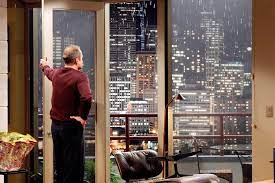

In [234]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib.ticker import PercentFormatter
plt.rcParams.update({ "figure.figsize" : (8, 5),"axes.facecolor" : "white", "axes.edgecolor":  "black"})
plt.rcParams["figure.facecolor"]= "w"
pd.plotting.register_matplotlib_converters()
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## Data Cleaning

### Data Overview

In [235]:
# importing eda raw data
df_eda = pd.read_csv('eda.csv')
df_eda.count()

date             21597
price            21597
house_id         21597
id               21597
id.1             21597
bedrooms         21597
bathrooms        21597
sqft_living      21597
sqft_lot         21597
floors           21597
waterfront       19206
view             21534
condition        21597
grade            21597
sqft_above       21597
sqft_basement    21145
yr_built         21597
yr_renovated     17749
zipcode          21597
lat              21597
long             21597
sqft_living15    21597
sqft_lot15       21597
dtype: int64

In [236]:
df_eda.head()
#df_eda['waterfront'].unique()

,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.000,7129300520,1,7129300520,3.000,1.000,1180.000,5650.000,1.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,2014-12-09,538000.000,6414100192,2,6414100192,3.000,2.250,2570.000,7242.000,2.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,2015-02-25,180000.000,5631500400,3,5631500400,2.000,1.000,770.000,10000.000,1.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,2014-12-09,604000.000,2487200875,4,2487200875,4.000,3.000,1960.000,5000.000,1.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,2015-02-18,510000.000,1954400510,5,1954400510,3.000,2.000,1680.000,8080.000,1.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


In [237]:
# change "date" dtype to datetime with format %Y/%m/%d
df_eda['date'] = pd.to_datetime(df_eda['date'])

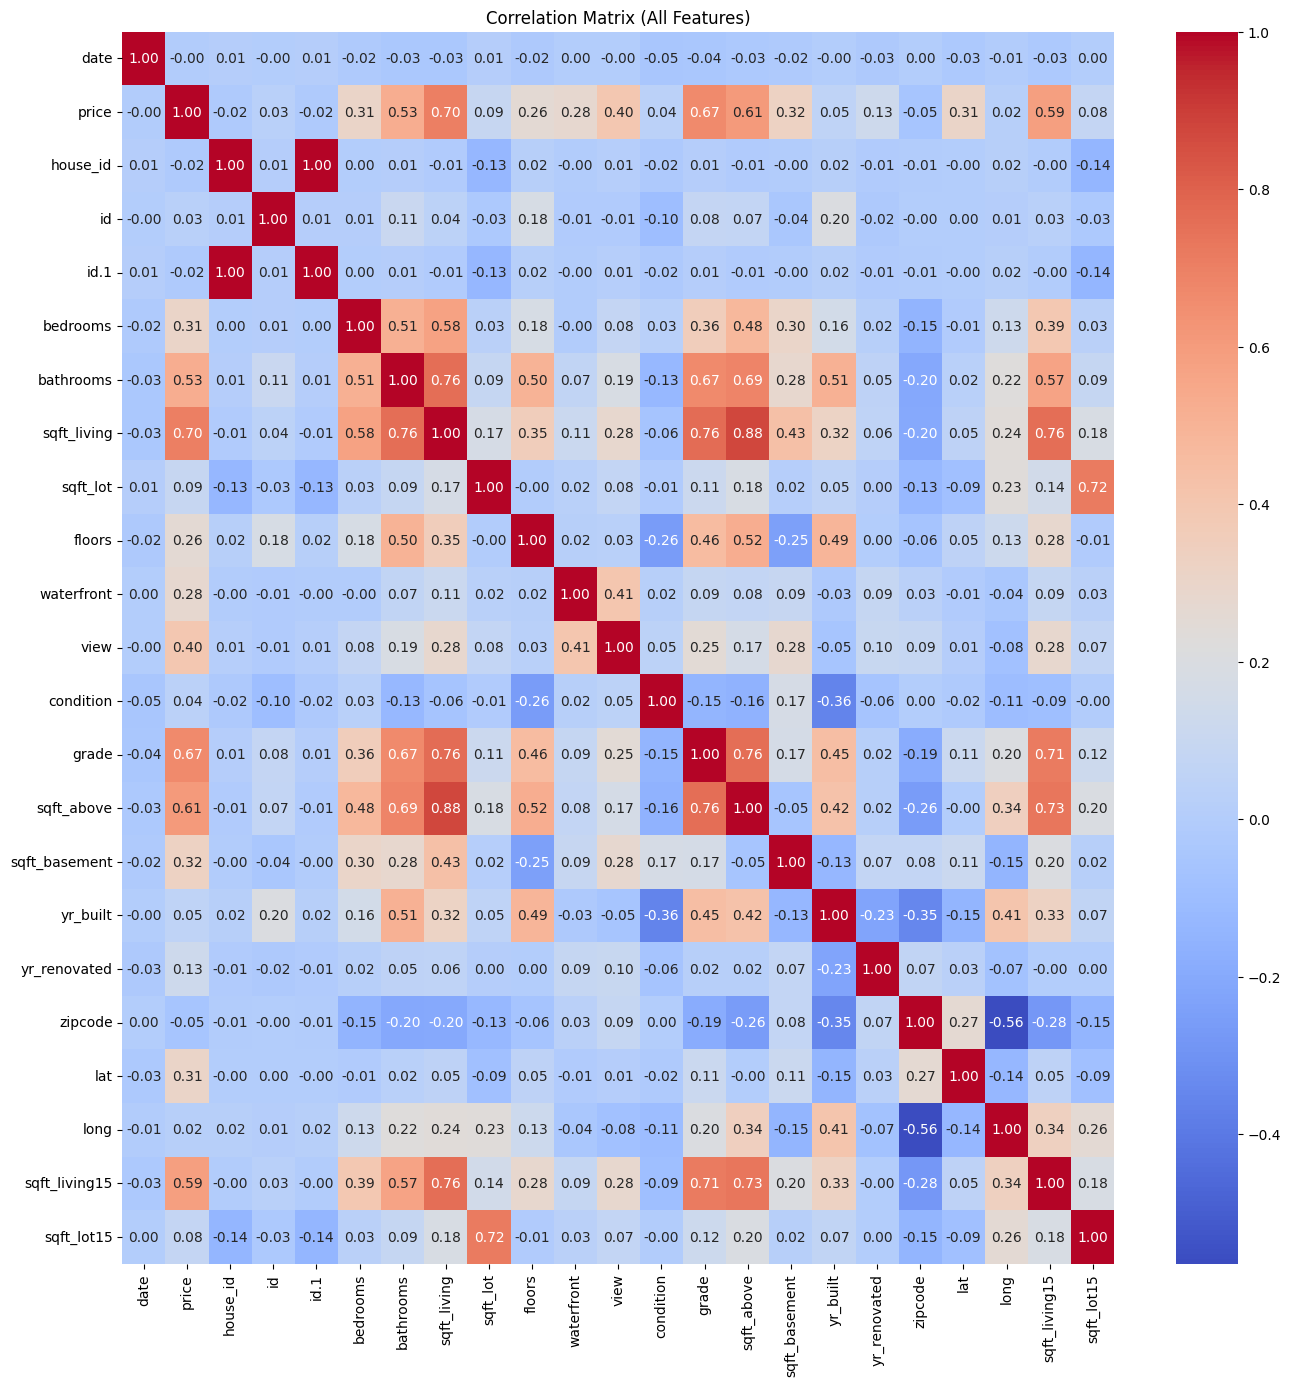

In [238]:
# Plot all Feature Correlation

# Korrelation berechnen
corr_matrix = df_eda.corr()

plt.figure(figsize=(16,16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (All Features)')
plt.show()

In [239]:
# check how many duplicated rows exist in the data frame
df_eda.duplicated().value_counts()

False    21597
Name: count, dtype: int64

<Axes: >

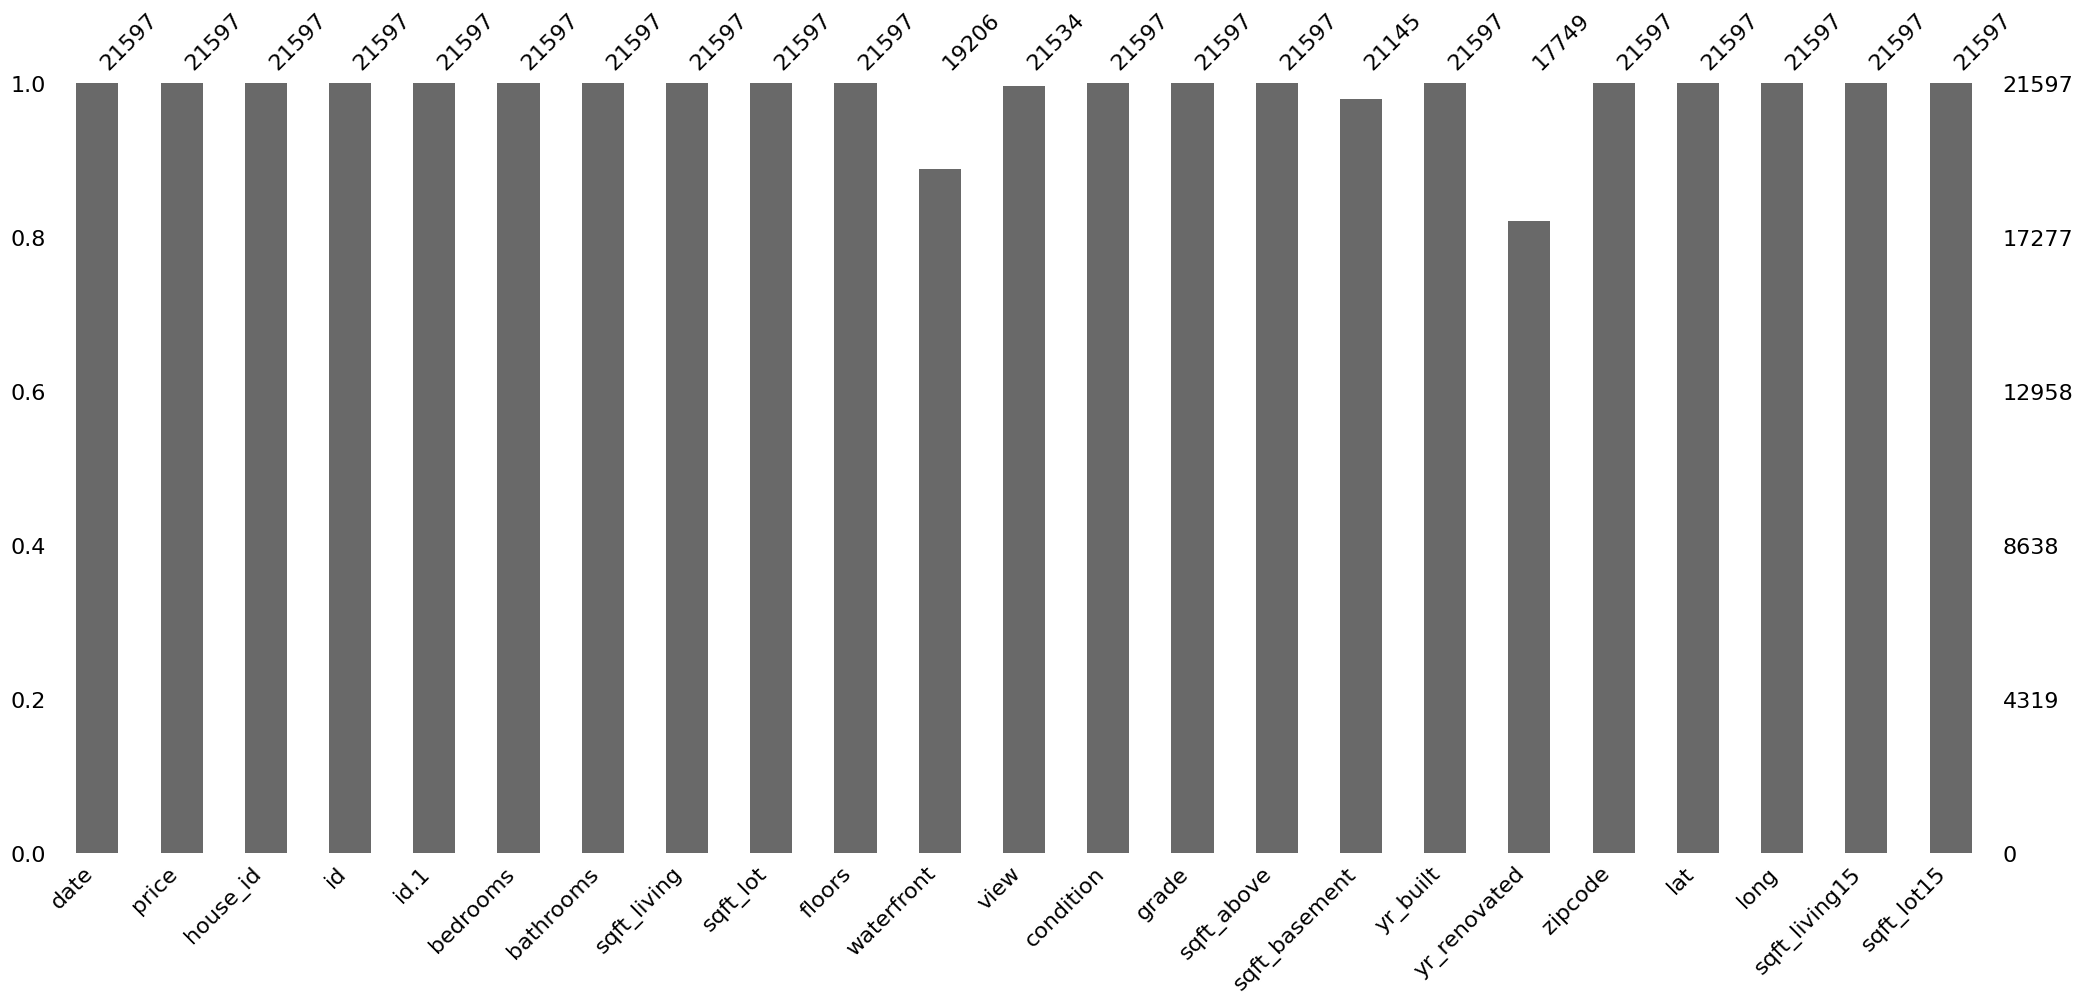

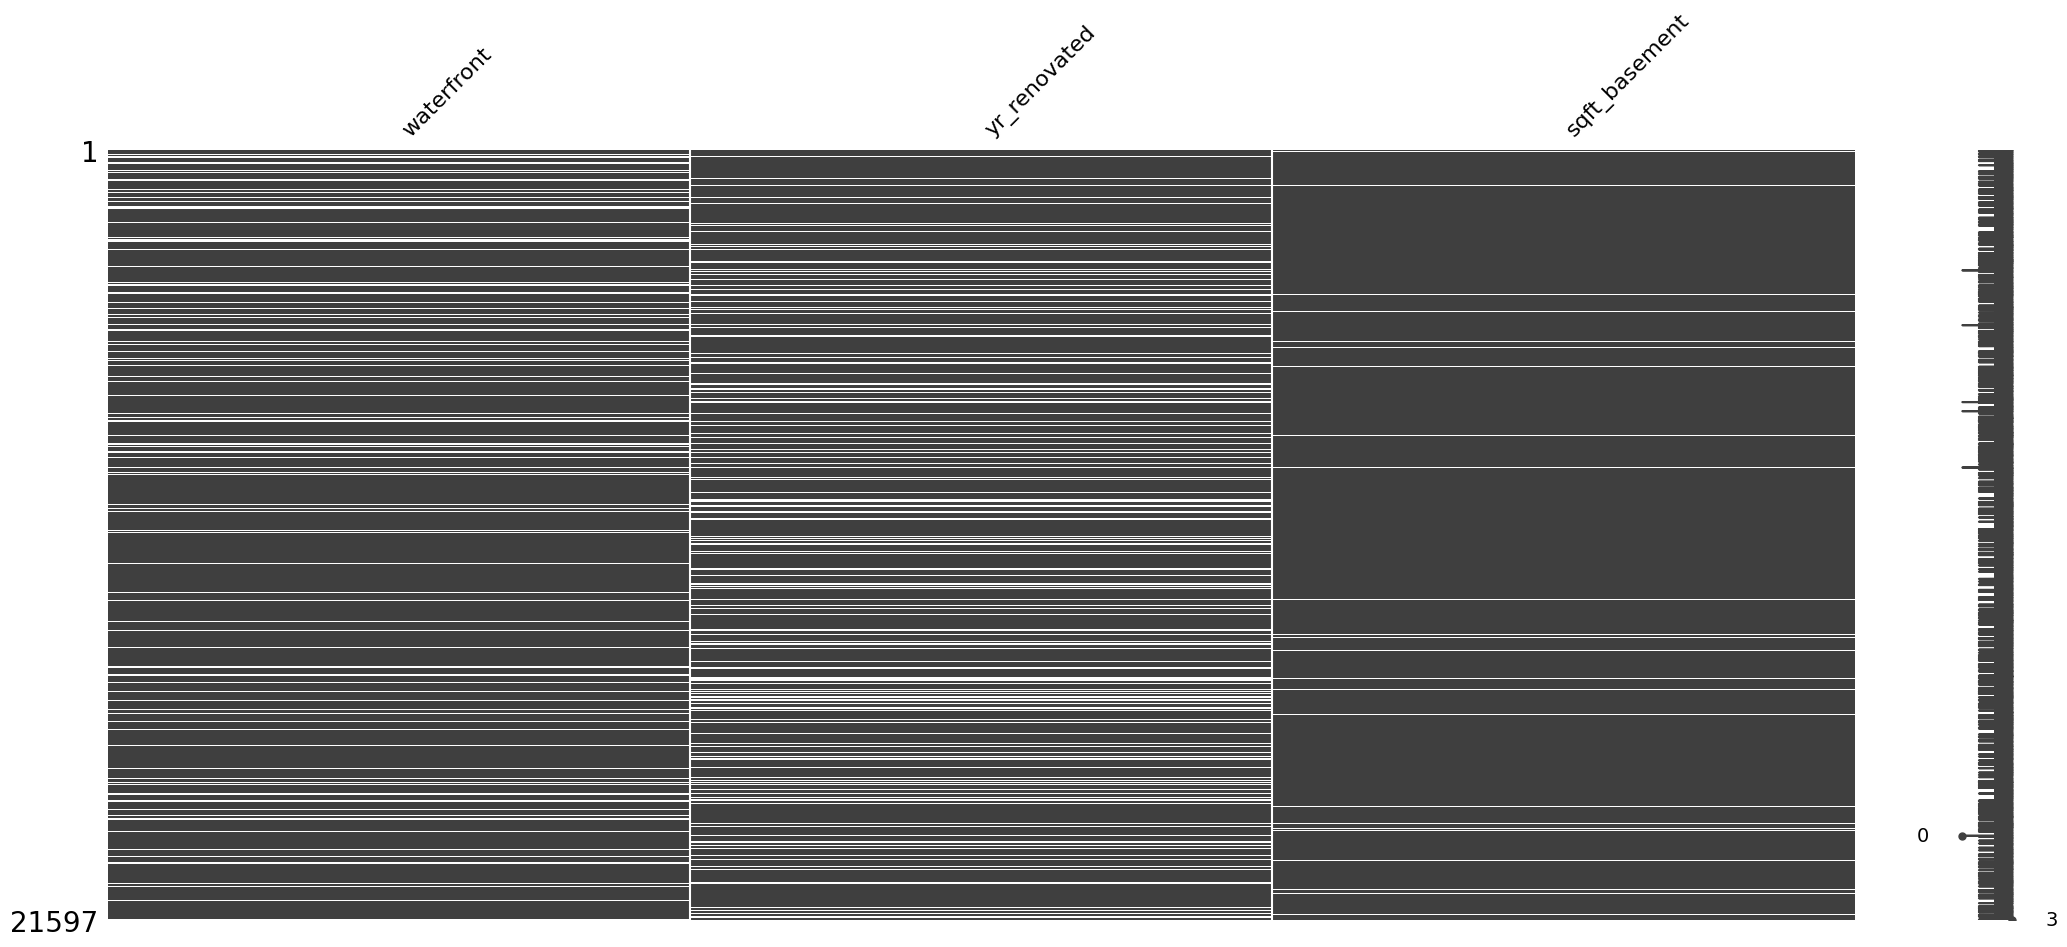

In [240]:
# import missingno
import missingno as msno
# display number of missing values per column
df_eda.isna().sum()

# plotting percentage of missing values per column
msno.bar(df_eda)
msno.matrix(df_eda[['waterfront','yr_renovated','sqft_basement']])


# Missing Data seams to be appear randomly becuase there is no clear pattern the 3 columns with missing Values

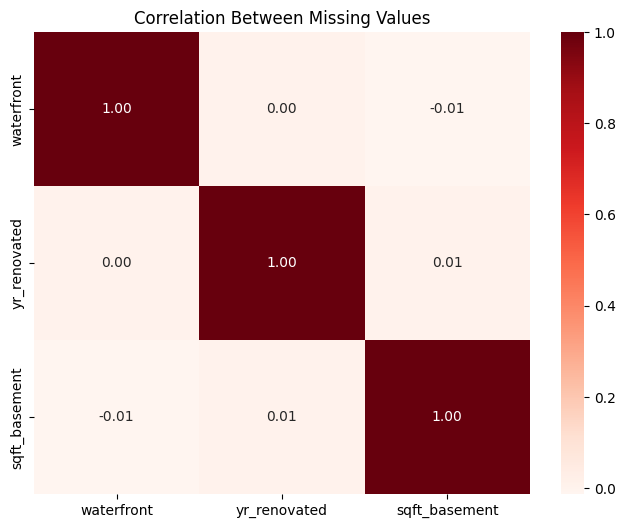

In [242]:
# Erzeuge eine DataFrame mit True/False, wo Werte fehlen
missing_df = df_eda[['waterfront', 'yr_renovated', 'sqft_basement']].isna()

# Konvertiere zu int (True → 1, False → 0), damit wir korrelieren können
missing_int = missing_df.astype(int)

corr_matrix = missing_int.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation Between Missing Values')
plt.show()

Through Correlation Matrix we can see more cleary there not a really hight relations to each other.

In [243]:
print(f"numbers of rows : {df_eda.shape[0]}")
print(f"missing values in waterfront : {round(df_eda.waterfront.isna().sum()/df_eda.shape[0]*100,2)} %")
print(f"missing values in yr_renovated : {round(df_eda.yr_renovated.isna().sum()/df_eda.shape[0]*100,2)} %")
print(f"missing values in sqft_basement frame : {round(df_eda.sqft_basement.isna().sum()/df_eda.shape[0]*100,2)} %")
print(f"missing values in data frame : {round(df_eda.isna().sum().sum()/(df_eda.shape[0]*df_eda.shape[1])*100,2)} %")

numbers of rows : 21597
missing values in waterfront : 11.07 %
missing values in yr_renovated : 17.82 %
missing values in sqft_basement frame : 2.09 %
missing values in data frame : 1.36 %


In [244]:
#df_eda_copy = df_eda.copy()
#df_wihtouth = df_eda_copy.dropna()
#df_wihtouth.shape[0]

In [245]:
#df_eda = df_eda.dropna()

In [246]:
# check data types in data frame
df_eda.dtypes

date             datetime64[ns]
price                   float64
house_id                  int64
id                        int64
id.1                      int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront              float64
view                    float64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
dtype: object

In [247]:
# replacing empty spaces with underscores in column names
df_eda.columns = df_eda.columns.str.replace(' ','_')
# changing all column names to lower case
df_eda.columns = df_eda.columns.str.lower()
# renaming last column
df_eda = df_eda.rename({'id.1':'sale_id'},axis=1)
df_eda.columns

Index(['date', 'price', 'house_id', 'id', 'sale_id', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [248]:
# Select relevant Columns 
columns_to_keep = [
    'price',
    'waterfront',
    'grade',
    'yr_renovated',
    'zipcode',
    'sqft_living',
    'sqft_above',
    'date',
    'house_id',
    'condition',
    'lat',
    'long'
]
df_eda = df_eda[columns_to_keep]
df_eda

,price,waterfront,grade,yr_renovated,zipcode,sqft_living,sqft_above,date,house_id,condition,lat,long
0,221900.000,NaN,7,0.000,98178,1180.000,1180.000,2014-10-13,7129300520,3,47.511,-122.257
1,538000.000,0.000,7,19910.000,98125,2570.000,2170.000,2014-12-09,6414100192,3,47.721,-122.319
2,180000.000,0.000,6,NaN,98028,770.000,770.000,2015-02-25,5631500400,3,47.738,-122.233
3,604000.000,0.000,7,0.000,98136,1960.000,1050.000,2014-12-09,2487200875,5,47.521,-122.393
4,510000.000,0.000,8,0.000,98074,1680.000,1680.000,2015-02-18,1954400510,3,47.617,-122.045
...,...,...,...,...,...,...,...,...,...,...,...,...
21592,360000.000,0.000,8,0.000,98103,1530.000,1530.000,2014-05-21,263000018,3,47.699,-122.346
21593,400000.000,0.000,8,0.000,98146,2310.000,2310.000,2015-02-23,6600060120,3,47.511,-122.362
21594,402101.000,0.000,7,0.000,98144,1020.000,1020.000,2014-06-23,1523300141,3,47.594,-122.299
21595,400000.000,NaN,8,0.000,98027,1600.000,1600.000,2015-01-16,291310100,3,47.535,-122.069


In [249]:
# rounding data
# Differenz zwischen Originalwert und gerundetem Wert
diff = df_eda['price'] - df_eda['price'].round(2)

# Zeige nur Werte, die nicht exakt zwei Nachkommastellen haben
df_eda[diff != 0].head()
# Strange that the float64 columns shows 3 Nachkommastellen

,price,waterfront,grade,yr_renovated,zipcode,sqft_living,sqft_above,date,house_id,condition,lat,long


In [250]:
df_eda['waterfront'] = df_eda['waterfront'].map({1.0: True, 0.0: False}).astype('boolean')

In [251]:
df_eda.waterfront.dtype

BooleanDtype

# What kind of property offers Jennifer Montgomery the best short-term resale potential while meeting her lifestyle needs?
- Renovated waterfront properties with high grade ratings sell at significantly higher prices than those with lower grade ratings.
- Properties in the top 10% most expensive zip codes appreciate more quickly over time.
- Larger renovated waterfront homes are significantly more expensive - size is a key factor in prestige and resale value.

In [280]:
df_h1 = df_eda[
    (df_eda['waterfront'] == True) &
    (df_eda['yr_renovated'].notna()) 
]


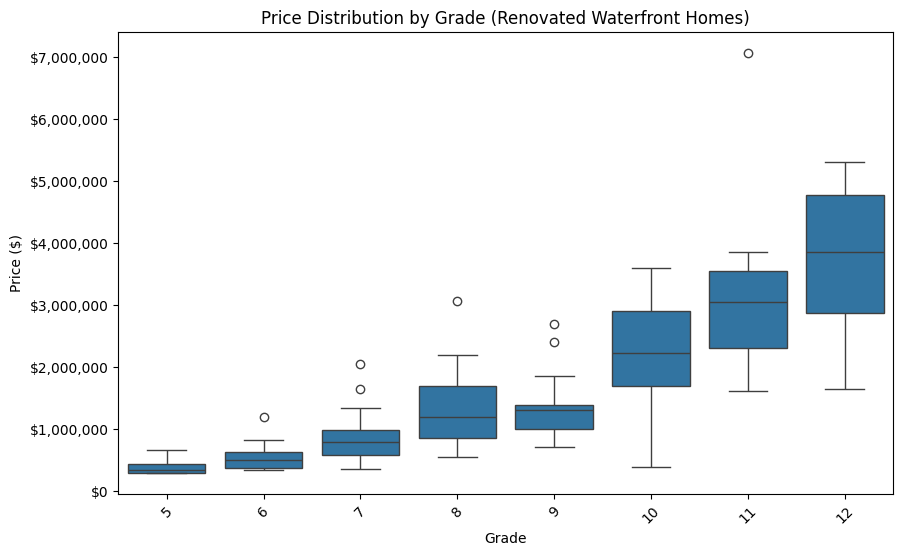

In [281]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_h1, x='grade', y='price')
plt.title('Price Distribution by Grade (Renovated Waterfront Homes)')
plt.ylabel('Price ($)')
plt.xlabel('Grade')
plt.xticks(rotation=45)
# 💡 Y-Achse mit Tausendertrennung
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.show()

In [262]:
# Top 10% Zipcodes nach mittlerem Preis
top_zipcodes = df_eda.groupby('zipcode')['price'].median().sort_values(ascending=False).head(
    int(len(df_eda['zipcode'].unique()) * 0.10)
).index

# Daten vorbereiten
df_h2 = df_eda[df_eda['zipcode'].isin(top_zipcodes)].copy()
df_h2['year_month'] = df_h2['date'].dt.to_period('M').dt.to_timestamp()



In [274]:
# 1. Filter: Nur Häuser, die Jennys Anforderungen erfüllen
df_jenny = df_eda[
    (df_eda['waterfront'] == True) &
    (df_eda['yr_renovated'].notna()) &
    (df_eda['grade'] >= 10)
].copy()

# 2. Top 10 % Zipcodes basierend auf Jennys Zielgruppe
top_zipcodes = df_jenny.groupby('zipcode')['price'].median().sort_values(ascending=False).head(
    int(len(df_jenny['zipcode'].unique()) * 0.10)
).index

# 3. Nur Daten aus diesen Zipcodes, für Jennys Haustyp
df_h2 = df_jenny[df_jenny['zipcode'].isin(top_zipcodes)].copy()

# 4. Zeitspalte vorbereiten
df_h2['year_month'] = df_h2['date'].dt.to_period('M').dt.to_timestamp()

In [275]:
top_zipcodes

Index([98004, 98033], dtype='int64', name='zipcode')

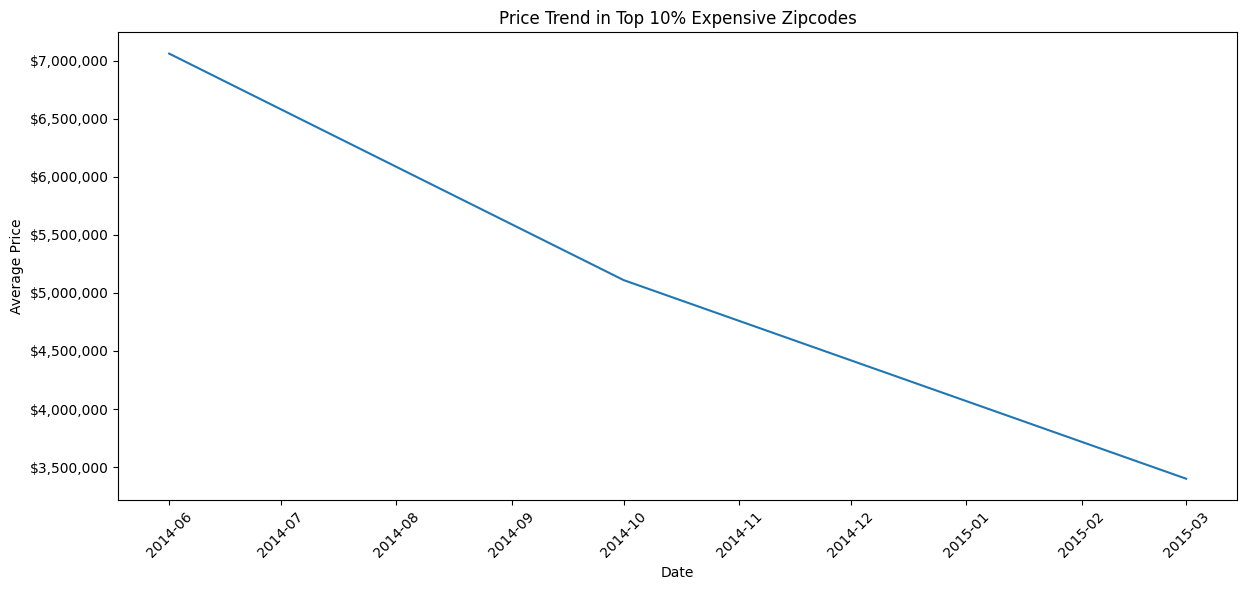

In [276]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_h2, x='year_month', y='price')
plt.title('Price Trend in Top 10% Expensive Zipcodes')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
# 💡 Y-Achse mit Tausendertrennung
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.show()


In [277]:
import plotly.express as px

fig = px.scatter_map(df_h2, 
                        lat="lat", 
                        lon="long", 
                        zoom=8, 
                        height=800,
                        width=800)

fig.show()

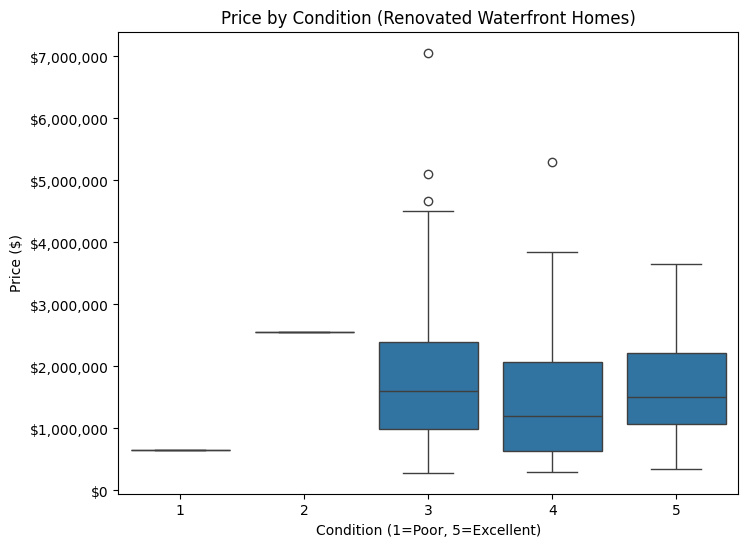

In [271]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_h3, x='condition', y='price')
plt.title('Price by Condition (Renovated Waterfront Homes)')
plt.xlabel('Condition (1=Poor, 5=Excellent)')
plt.ylabel('Price ($)')

# 💡 Y-Achse mit Tausendertrennung
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.show()


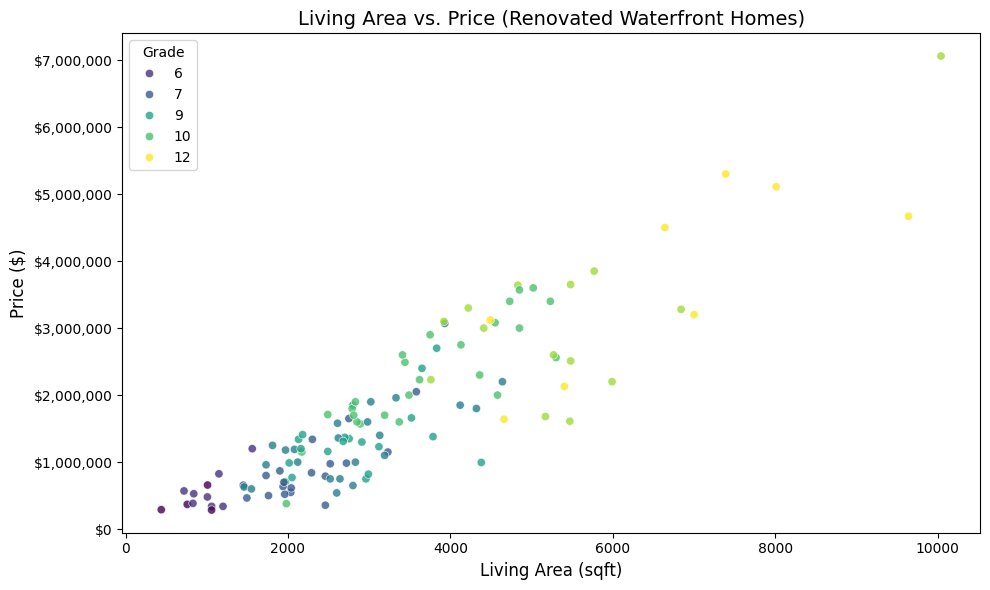

In [270]:

# 🔹 Filter: Nur Jennifers Zielgruppe
df_jenny = df_eda[
    (df_eda['waterfront'] == True) &
    (df_eda['yr_renovated'].notna())
].copy()

# 🔹 Scatterplot: Wohnfläche vs. Preis
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_jenny,
    x='sqft_living',
    y='price',
    hue='grade',
    palette='viridis',
    alpha=0.8
)

# 🔹 Achsentitel & Formatierung
plt.title('Living Area vs. Price (Renovated Waterfront Homes)', fontsize=14)
plt.xlabel('Living Area (sqft)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

# 💡 Y-Achse mit Tausendertrennung
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

plt.legend(title='Grade')
plt.tight_layout()
plt.show()
